## Loading Data

In [145]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.feature_selection import mutual_info_classif
import scipy.stats as stats
from scipy.stats import chi2_contingency
import itertools

#from github
username = "datagus"
repository = "ASDA2025"
directory = "datasets/homework_week9/housing.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
housing_df = pd.read_csv(github_url)

## Basic Data Inspection

In [146]:
housing_df.shape

(1460, 81)

In [147]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [148]:
housing_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [149]:
housing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [150]:
# Identify numerical columns
num_cols = housing_df.select_dtypes(include=['int64', 'float64']).columns.tolist()


print("Numeric variables:", len(num_cols))



Numeric variables: 38


## Dealing with Missing Values

In [151]:
# Percent missing for each variable
missing = (housing_df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
missing


PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [152]:
# Drop unwanted categorical columns
housing_df.drop(['PoolQC','MiscFeature','Alley','Fence'], axis=1, inplace=True)

# Define categorical columns
cat_cols = housing_df.select_dtypes(include=['object', 'category']).columns.tolist()

In [153]:
none_fill_cols = [
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "MasVnrType"
]

for col in none_fill_cols:
    if col in housing_df.columns:
        housing_df[col] = housing_df[col].fillna("None")

In [154]:
# Percent missing for each variable
missing = (housing_df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
missing


LotFrontage    17.739726
GarageYrBlt     5.547945
MasVnrArea      0.547945
Electrical      0.068493
dtype: float64

In [155]:
# Fill LotFrontage with median of neighborhood
housing_df['LotFrontage'] = housing_df['LotFrontage'].fillna(housing_df['LotFrontage'].median())

# Fill GarageYrBlt and MasVnrArea empty values with 0
housing_df['MasVnrArea'] = housing_df['MasVnrArea'].fillna(0)
housing_df['GarageYrBlt'] = housing_df['GarageYrBlt'].fillna(0)

# Fill missing values in 'Electrical' with the mode
housing_df['Electrical'] = housing_df['Electrical'].fillna(housing_df['Electrical'].mode()[0])

# Percent missing for each variable
missing = (housing_df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
missing

Series([], dtype: float64)

## Inspecting Distributions

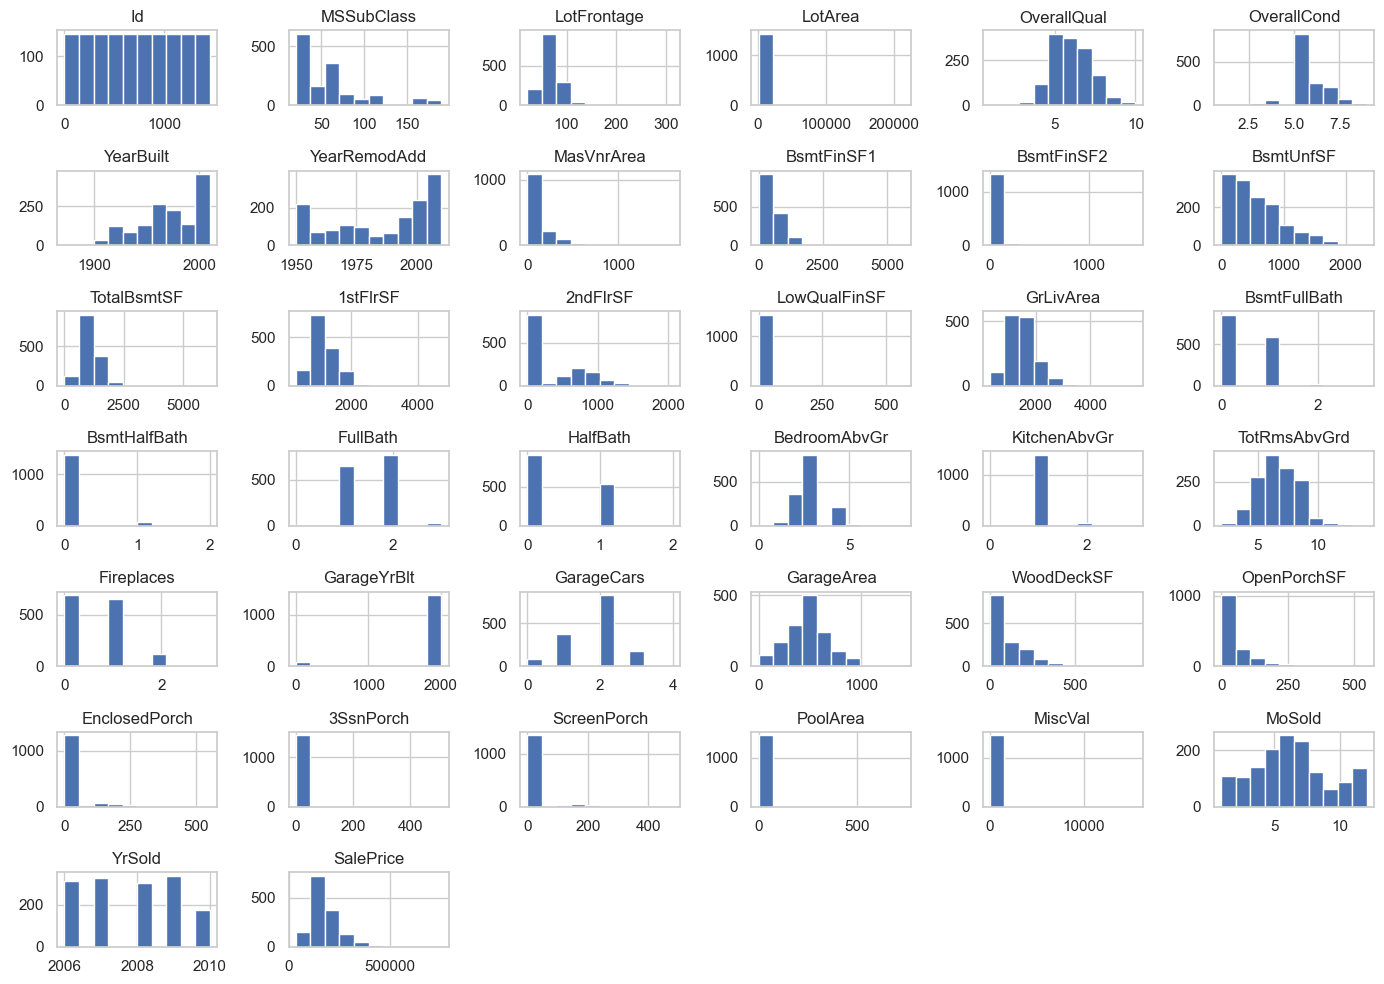

In [156]:
housing_df[num_cols].hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

## Selecting Numeric Features

In [157]:
skew_values = housing_df[num_cols].skew().sort_values(ascending=False)
skew_values

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
LotFrontage       2.409147
OpenPorchSF       2.364342
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
Id                0.000000
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
G

In [158]:
drop_cols = [
    "MiscVal", "PoolArea", "3SsnPorch", "LowQualFinSF", "KitchenAbvGr", 
    "BsmtFinSF2", "ScreenPorch", "BsmtHalfBath"
]

housing_df = housing_df.drop(columns=drop_cols)


In [159]:


log_transform_cols = [
    "MasVnrArea", "LotFrontage", "EnclosedPorch", "OpenPorchSF",
    "SalePrice", "BsmtFinSF1", "WoodDeckSF", "TotalBsmtSF", 
    "1stFlrSF", "GrLivArea", "LotArea"
]

for col in log_transform_cols:
    housing_df[col + "_log"] = np.log1p(housing_df[col])


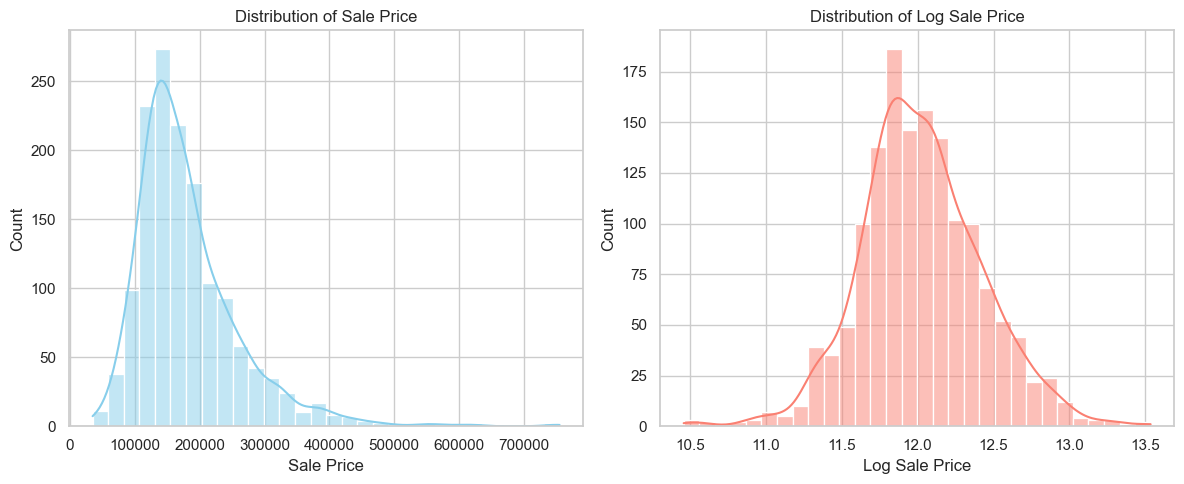

In [160]:
plt.figure(figsize=(12,5))

# Original SalePrice
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
sns.histplot(housing_df['SalePrice'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')

# Log-transformed SalePrice
plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
sns.histplot(housing_df['SalePrice_log'], kde=True, bins=30, color='salmon')
plt.title('Distribution of Log Sale Price')
plt.xlabel('Log Sale Price')

plt.tight_layout()
plt.show()

In [161]:
numeric_var = [
    'SalePrice_log','MSSubClass', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
    'BsmtUnfSF', '2ndFlrSF', 'BsmtFullBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
    'GarageCars', 'GarageArea', 'MoSold', 'YrSold',
    'MasVnrArea_log', 'LotFrontage_log', 'EnclosedPorch_log',
    'OpenPorchSF_log', 'BsmtFinSF1_log', 'WoodDeckSF_log',
    'TotalBsmtSF_log', '1stFlrSF_log', 'GrLivArea_log', 'LotArea_log'
]

cols_to_drop = ["LotArea", "MasVnrArea", "LotFrontage", "OpenPorchSF", "EnclosedPorch",
                "BsmtFinSF1", "WoodDeckSF", "TotalBsmtSF", "1stFlrSF", "GrLivArea"]
housing_df = housing_df.drop(columns=cols_to_drop)


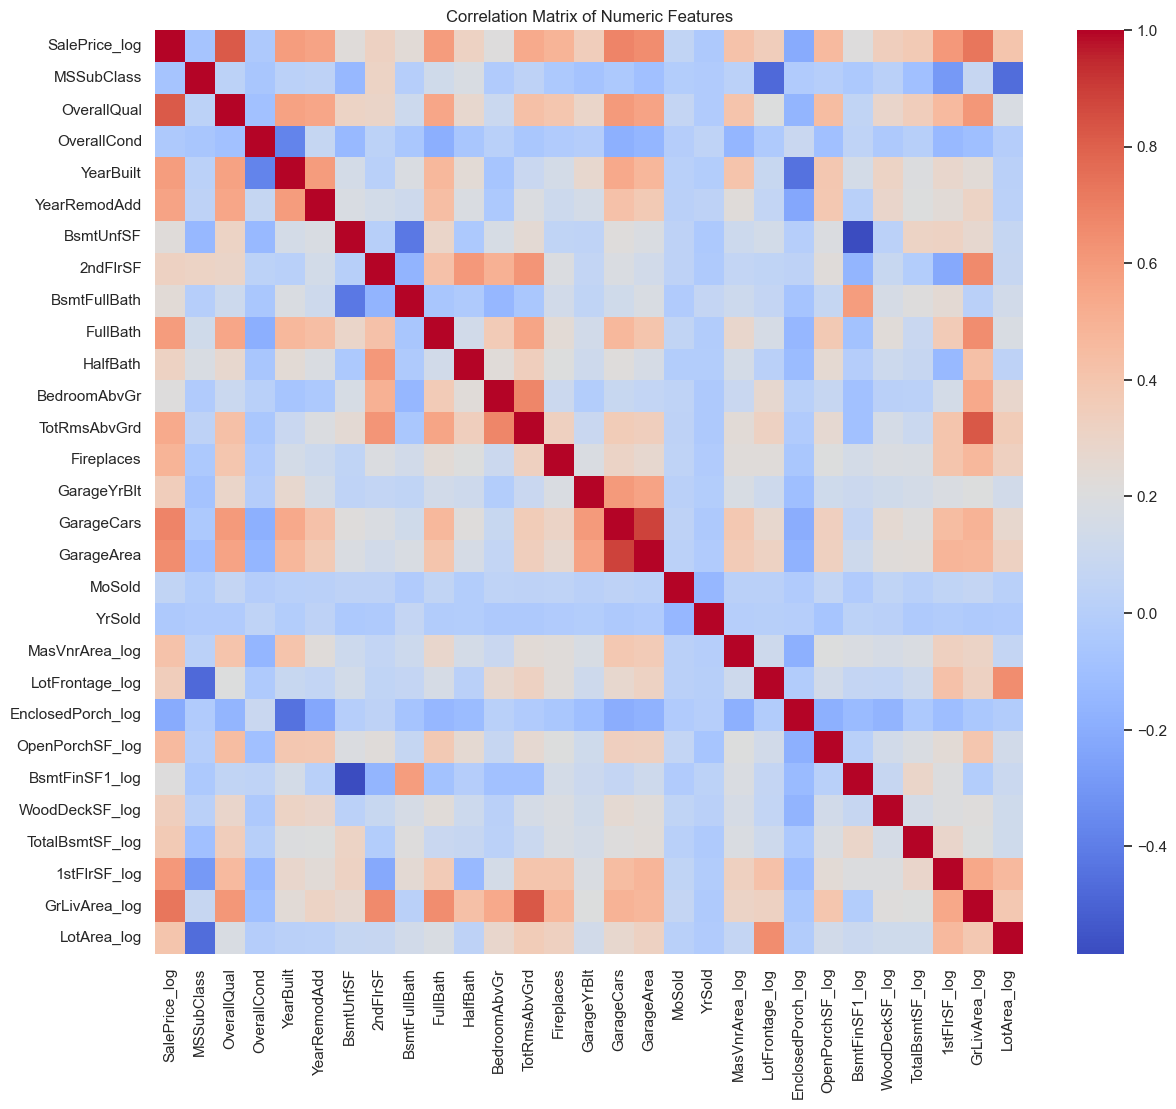

Correlation with SalePrice_log:
 SalePrice_log        1.000000
OverallQual          0.817185
GrLivArea_log        0.730254
GarageCars           0.680625
GarageArea           0.650888
1stFlrSF_log         0.608955
FullBath             0.594771
YearBuilt            0.586570
YearRemodAdd         0.565608
TotRmsAbvGrd         0.534422
Fireplaces           0.489450
OpenPorchSF_log      0.459948
MasVnrArea_log       0.413318
LotArea_log          0.399923
TotalBsmtSF_log      0.372838
GarageYrBlt          0.349013
LotFrontage_log      0.346237
WoodDeckSF_log       0.343039
2ndFlrSF             0.319300
HalfBath             0.313982
BsmtFullBath         0.236224
BsmtUnfSF            0.221985
BedroomAbvGr         0.209043
BsmtFinSF1_log       0.208099
MoSold               0.057330
OverallCond         -0.036868
YrSold              -0.037263
MSSubClass          -0.073959
EnclosedPorch_log   -0.207263
Name: SalePrice_log, dtype: float64

Variance Inflation Factors (VIF):
               feature    

In [162]:
# Numeric columns 
# Correlation matrix
corr_matrix = housing_df[numeric_var].corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()


# list variables highly correlated with target
target_corr = corr_matrix['SalePrice_log'].sort_values(ascending=False)
print("Correlation with SalePrice_log:\n", target_corr)

# VIF calculation
X = housing_df[numeric_var].drop(columns=['SalePrice_log'])  # VIF does not include target
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) 
                   for i in range(X_const.shape[1])]

print("\nVariance Inflation Factors (VIF):\n", vif_data.sort_values(by="VIF", ascending=False))

In [163]:
# Drop highly collinear variables based on VIF and correlation analysis
drop_numeric_cols = [
    "Id",                 # identifier, not useful for modeling
    "1stFlrSF_log",      # redundant with GrLivArea_log
    "2ndFlrSF",          # redundant with GrLivArea_log
    "TotRmsAbvGrd",      # highly correlated with GrLivArea_log
    "GarageArea",        # highly correlated with GarageCars
    "OverallCond",       # very low correlation with target
    "YrSold",            # very low correlation with target
    "MoSold",            # very low correlation with target
    "MSSubClass",         # low correlation, mostly categorical
    "SalePrice",         # original target, use log version instead
    "LotFrontage_log",  # low correlation with target
    "BsmtUnfSF"      # low correlation with target
]

# Drop these columns
housing_df = housing_df.drop(columns=drop_numeric_cols)

# Check the remaining numeric columns
numeric_cols_final = housing_df.select_dtypes(include=[np.number]).columns
print("Remaining numeric columns:", numeric_cols_final)


Remaining numeric columns: Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'BsmtFullBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'Fireplaces', 'GarageYrBlt', 'GarageCars',
       'MasVnrArea_log', 'EnclosedPorch_log', 'OpenPorchSF_log',
       'SalePrice_log', 'BsmtFinSF1_log', 'WoodDeckSF_log', 'TotalBsmtSF_log',
       'GrLivArea_log', 'LotArea_log'],
      dtype='object')


## Selecting Categorical Features

In [164]:
anova_results = {}

for col in cat_cols:
    # Get the groups
    groups = [group["SalePrice_log"].values for name, group in housing_df.groupby(col)]
    
    # Skip columns with less than 2 groups
    if len(groups) < 2:
        print(f"Skipping {col} — only one group available")
        continue
    
    # Skip groups with zero variance
    if any(np.var(g) == 0 for g in groups):
        print(f"Skipping {col} — at least one group has zero variance")
        continue
    
    # Run ANOVA
    f_val, p_val = stats.f_oneway(*groups)
    
    # Store both F and p values
    anova_results[col] = {'F_value': f_val, 'p_value': p_val}

# Convert to DataFrame
anova_df = pd.DataFrame.from_dict(anova_results, orient='index')
anova_df = anova_df.sort_values(by='p_value')
print(anova_df)

Skipping Utilities — at least one group has zero variance
Skipping Condition2 — at least one group has zero variance
Skipping RoofMatl — at least one group has zero variance
Skipping Exterior1st — at least one group has zero variance
Skipping Exterior2nd — at least one group has zero variance
Skipping ExterCond — at least one group has zero variance
Skipping Heating — at least one group has zero variance
Skipping HeatingQC — at least one group has zero variance
Skipping Electrical — at least one group has zero variance
Skipping Functional — at least one group has zero variance
                  F_value        p_value
Neighborhood    79.520526  4.041201e-243
ExterQual      415.304259  6.930372e-195
BsmtQual       300.392915  2.029970e-188
KitchenQual    393.320922  4.438817e-187
GarageFinish   298.769591  4.058066e-151
GarageType     121.796238  8.430356e-125
FireplaceQu    131.198588  6.961918e-115
Foundation     126.806779  1.350599e-111
BsmtFinType1    71.381818   4.320809e-78
MasVnr

In [165]:
drop_cols = ['Utilities','Condition2','RoofMatl','Exterior1st','Exterior2nd',
             'ExterCond','Heating','HeatingQC','Electrical','Functional', 'Street','LandSlope']
housing_df = housing_df.drop(columns=drop_cols)

# Verify
print(housing_df.select_dtypes(include=['object', 'category']).columns.tolist())


['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'MasVnrType', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'CentralAir', 'KitchenQual', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [166]:
from itertools import combinations
# Remaining categorical columns
cat_cols = ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'Neighborhood', 
            'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'MasVnrType', 'ExterQual',  
            'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
            'BsmtFinType2', 'CentralAir', 
            'KitchenQual', 'FireplaceQu', 'GarageType', 'GarageFinish', 
            'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

high_dep_pairs = []

# Check pairwise chi-square
for col1, col2 in combinations(cat_cols, 2):
    contingency_table = pd.crosstab(housing_df[col1], housing_df[col2])
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        continue  # skip if any variable has only 1 unique category
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    if p < 0.05:  # significant association → dependent
        high_dep_pairs.append((col1, col2, p))

# Convert to DataFrame for readability
chi_square_df = pd.DataFrame(high_dep_pairs, columns=['col1', 'col2', 'p_value'])
chi_square_df = chi_square_df.sort_values(by='p_value')
print(chi_square_df)


             col1           col2   p_value
314      SaleType  SaleCondition  0.000000
302  GarageFinish     GarageQual  0.000000
303  GarageFinish     GarageCond  0.000000
296    GarageType   GarageFinish  0.000000
212      BsmtQual       BsmtCond  0.000000
..            ...            ...       ...
45       LotShape     GarageCond  0.033502
106    Condition1   BsmtFinType1  0.037970
267  BsmtFinType2     GarageQual  0.039491
231      BsmtCond    FireplaceQu  0.041111
73      LotConfig     CentralAir  0.043632

[315 rows x 3 columns]


In [167]:
# Count how many times each variable appears in dependent pairs
from collections import Counter

all_cols = list(chi_square_df['col1']) + list(chi_square_df['col2'])
col_counts = Counter(all_cols)

# Show variables most frequently involved in dependent pairs
col_counts.most_common()


[('GarageType', 26),
 ('BsmtQual', 26),
 ('BsmtFinType1', 26),
 ('BsmtExposure', 26),
 ('Neighborhood', 26),
 ('BldgType', 26),
 ('GarageFinish', 25),
 ('MSZoning', 25),
 ('Foundation', 25),
 ('ExterQual', 25),
 ('KitchenQual', 25),
 ('HouseStyle', 25),
 ('FireplaceQu', 25),
 ('PavedDrive', 25),
 ('MasVnrType', 24),
 ('CentralAir', 24),
 ('BsmtCond', 23),
 ('GarageCond', 23),
 ('LotShape', 23),
 ('SaleCondition', 23),
 ('BsmtFinType2', 22),
 ('GarageQual', 21),
 ('LandContour', 21),
 ('RoofStyle', 21),
 ('SaleType', 19),
 ('Condition1', 16),
 ('LotConfig', 14)]

In [168]:
# Set to track dropped variables
to_drop = set()

for col1, col2 in zip(chi_square_df['col1'], chi_square_df['col2']):
    if col1 not in to_drop and col2 not in to_drop:
        # Decide to drop col2 (or apply domain logic)
        to_drop.add(col2)

print(to_drop)

{'GarageFinish', 'Condition1', 'GarageCond', 'CentralAir', 'LandContour', 'MasVnrType', 'BldgType', 'KitchenQual', 'Neighborhood', 'FireplaceQu', 'HouseStyle', 'BsmtQual', 'BsmtFinType2', 'LotConfig', 'BsmtFinType1', 'BsmtExposure', 'Foundation', 'LotShape', 'BsmtCond', 'PavedDrive', 'GarageQual', 'RoofStyle', 'SaleType', 'ExterQual', 'SaleCondition', 'GarageType'}


In [169]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

cat_cols = housing_df.select_dtypes(include=['object', 'category']).columns
v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            v_matrix.loc[col1, col2] = 1.0
        else:
            v_matrix.loc[col1, col2] = cramers_v(housing_df[col1], housing_df[col2])

v_matrix = v_matrix.astype(float)

threshold = 0.6

high_corr_pairs = []

for col1 in v_matrix.columns:
    for col2 in v_matrix.columns:
        if col1 < col2:
            v = v_matrix.loc[col1, col2]
            if v > threshold:
                high_corr_pairs.append((col1, col2, v))

high_corr_pairs

[('MSZoning', 'Neighborhood', 0.6524799881463361),
 ('GarageFinish', 'GarageType', 0.6872189796273703),
 ('GarageCond', 'GarageQual', 0.7054642145501732)]

In [170]:
drop_cols = ['MSZoning', 'GarageFinish', 'GarageCond']
housing_df = housing_df.drop(columns=drop_cols)

# verify
print(housing_df.select_dtypes(include=['object', 'category']).columns.tolist())


['LotShape', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'MasVnrType', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'CentralAir', 'KitchenQual', 'FireplaceQu', 'GarageType', 'GarageQual', 'PavedDrive', 'SaleType', 'SaleCondition']


In [171]:
drop_cols = ['LandContour', 'LotConfig', 'Condition1', 'RoofStyle', 'MasVnrType', 'BsmtFinType2', 'PavedDrive', 'SaleType']
housing_df = housing_df.drop(columns=drop_cols)

# verify
print(housing_df.select_dtypes(include=['object', 'category']).columns.tolist())

['LotShape', 'Neighborhood', 'BldgType', 'HouseStyle', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'CentralAir', 'KitchenQual', 'FireplaceQu', 'GarageType', 'GarageQual', 'SaleCondition']


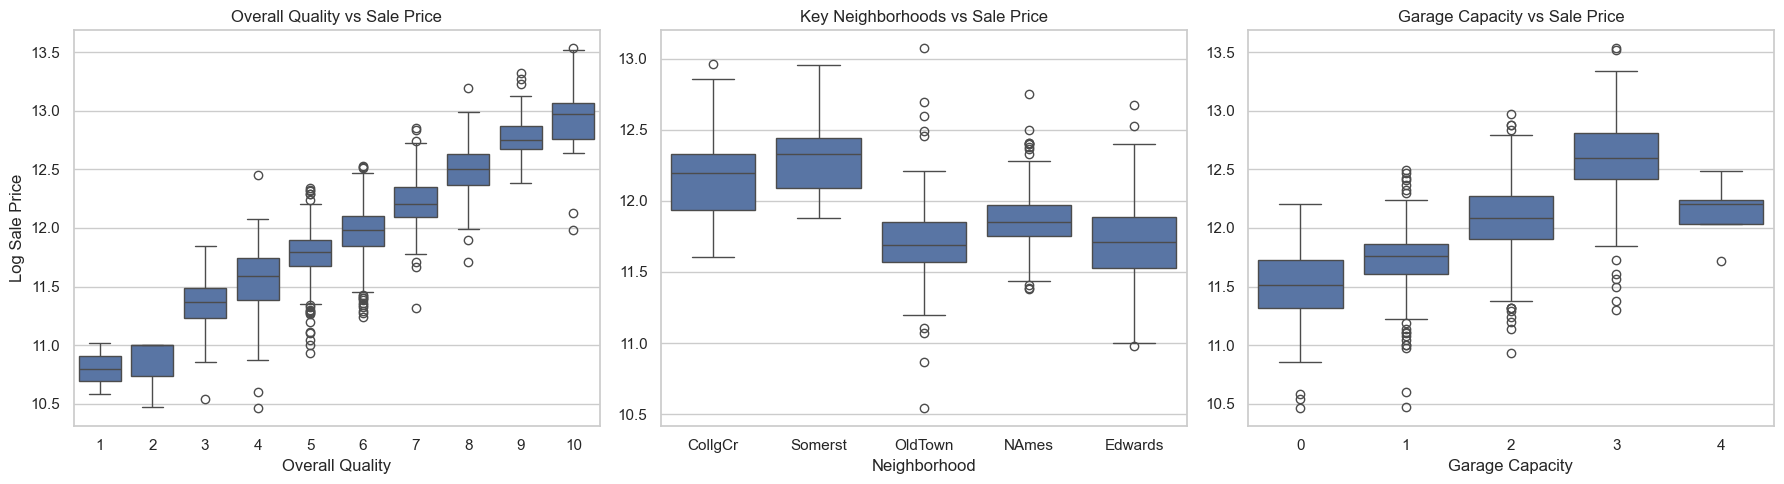

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- First tightplot: Overall Quality, Neighborhood, Garage Capacity ---
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Overall Quality
sns.boxplot(x='OverallQual', y='SalePrice_log', data=housing_df, ax=axes[0])
axes[0].set_title('Overall Quality vs Sale Price')
axes[0].set_xlabel('Overall Quality')
axes[0].set_ylabel('Log Sale Price')

# Key Neighborhoods
key_neighborhoods = ['NAmes', 'CollgCr', 'OldTown', 'Edwards', 'Somerst']
sns.boxplot(
    x='Neighborhood', 
    y='SalePrice_log', 
    data=housing_df[housing_df['Neighborhood'].isin(key_neighborhoods)],
    ax=axes[1]
)
axes[1].set_title('Key Neighborhoods vs Sale Price')
axes[1].set_xlabel('Neighborhood')
axes[1].set_ylabel('')

# Garage Capacity
sns.boxplot(x='GarageCars', y='SalePrice_log', data=housing_df, ax=axes[2])
axes[2].set_title('Garage Capacity vs Sale Price')
axes[2].set_xlabel('Garage Capacity')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


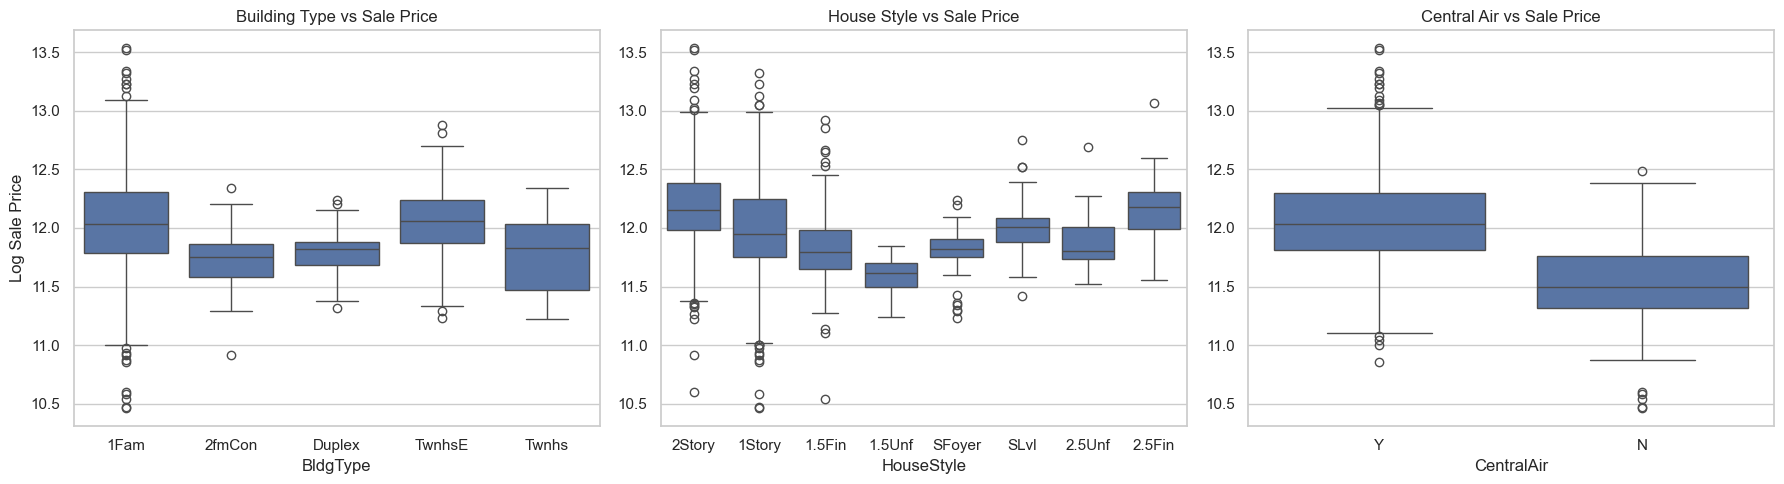

In [173]:
# --- Second tightplot: BldgType, HouseStyle, CentralAir ---
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# BldgType

sns.boxplot(x='BldgType', y='SalePrice_log', data=housing_df, ax=axes[0])
axes[0].set_title('Building Type vs Sale Price')
axes[0].set_xlabel('BldgType')
axes[0].set_ylabel('Log Sale Price')

# HouseStyle
sns.boxplot(x='HouseStyle', y='SalePrice_log', data=housing_df, ax=axes[1])
axes[1].set_title('House Style vs Sale Price')
axes[1].set_xlabel('HouseStyle')
axes[1].set_ylabel('')

# CentralAir
sns.boxplot(x='CentralAir', y='SalePrice_log', data=housing_df, ax=axes[2])
axes[2].set_title('Central Air vs Sale Price')
axes[2].set_xlabel('CentralAir')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


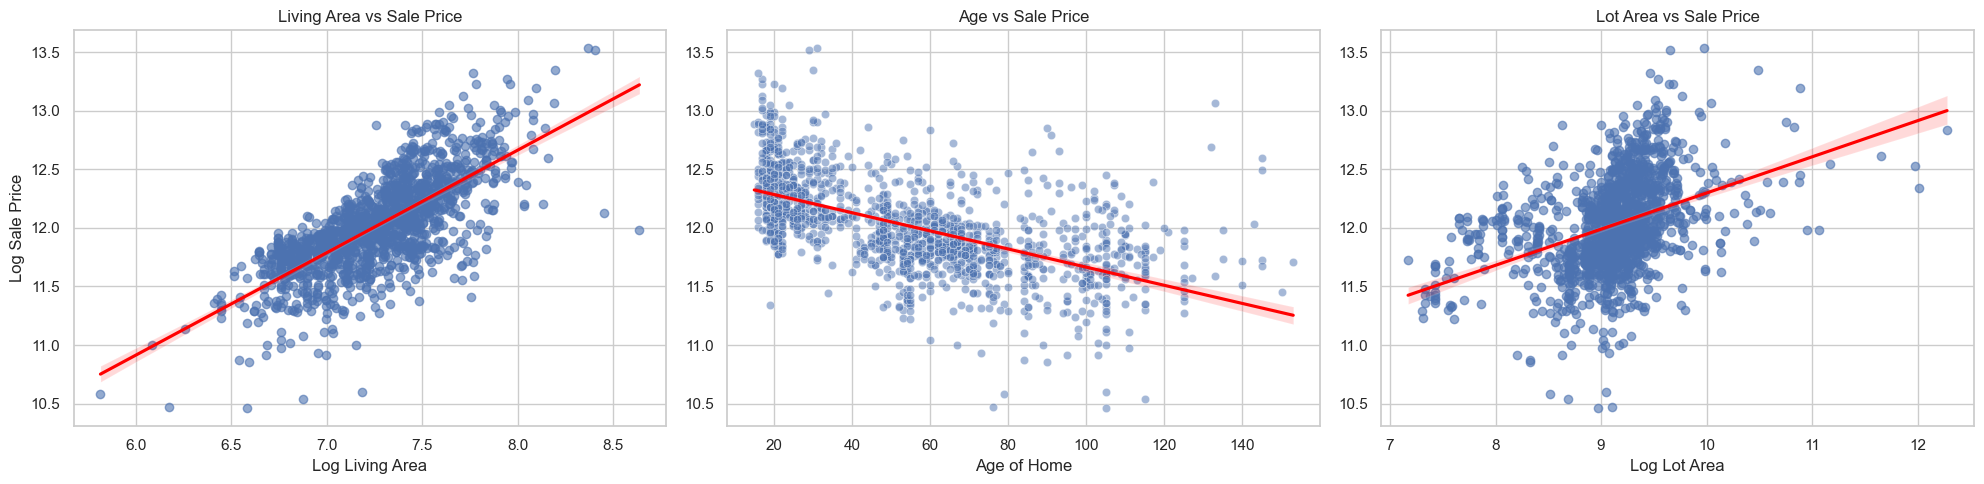

In [174]:

sns.set_theme(style="whitegrid")

# Age of Home
housing_df["Home_Age"] = 2025 - housing_df["YearBuilt"]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Living Area vs Sale Price
sns.regplot(
    x='GrLivArea_log', y='SalePrice_log',
    data=housing_df,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'},
    ax=axes[0]
)
axes[0].set_title('Living Area vs Sale Price')
axes[0].set_xlabel('Log Living Area')
axes[0].set_ylabel('Log Sale Price')

# Age of Home vs Sale Price
sns.scatterplot(
    x='Home_Age', y='SalePrice_log',
    data=housing_df,
    alpha=0.5,
    ax=axes[1]
)
sns.regplot(
    x='Home_Age', y='SalePrice_log',
    data=housing_df,
    scatter=False, color='red',
    ax=axes[1]
)
axes[1].set_title('Age vs Sale Price')
axes[1].set_xlabel('Age of Home')
axes[1].set_ylabel('')

# Lot Area vs Sale Price
sns.regplot(
    x='LotArea_log', y='SalePrice_log',
    data=housing_df,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'},
    ax=axes[2]
)
axes[2].set_title('Lot Area vs Sale Price')
axes[2].set_xlabel('Log Lot Area')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


## Ordinal Mapping and one-hot encoding

In [175]:
for col in ['ExterQual','BsmtQual','KitchenQual','FireplaceQu']:
    print(col, housing_df[col].unique())


ExterQual ['Gd' 'TA' 'Ex' 'Fa']
BsmtQual ['Gd' 'TA' 'Ex' 'None' 'Fa']
KitchenQual ['Gd' 'TA' 'Ex' 'Fa']
FireplaceQu ['None' 'TA' 'Gd' 'Fa' 'Ex' 'Po']


In [176]:
ordinal_mapping = {
    # ExterQual & KitchenQual
    'ExterQual': {'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'KitchenQual': {'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    
    # BsmtQual
    'BsmtQual': {'None': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    
    # FireplaceQu
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    
    # BsmtCond & GarageQual
    'BsmtCond': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageQual': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    
    # BsmtExposure
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    
    # BsmtFinType1
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},

}

# Apply mapping
for col, mapping in ordinal_mapping.items():
    housing_df[col] = housing_df[col].map(mapping)

# Check results
housing_df[list(ordinal_mapping.keys())].head()


,ExterQual,KitchenQual,BsmtQual,FireplaceQu,BsmtCond,GarageQual,BsmtExposure,BsmtFinType1
0,3,3,3,0,3,3,1,6
1,2,2,3,3,3,3,4,5
2,3,3,3,3,3,3,2,6
3,2,3,2,4,4,3,1,5
4,3,3,3,3,3,3,3,6


In [177]:
# Columns to check
onehot_cols = ['LotShape', 'Neighborhood', 'BldgType', 'HouseStyle', 
               'Foundation', 'CentralAir', 'GarageType', 'SaleCondition']

for col in onehot_cols:
    print(f"Feature: {col}")
    counts = housing_df[col].value_counts()
    proportions = housing_df[col].value_counts(normalize=True)
    print("Counts:")
    print(counts)
    print("Proportion:")
    print(proportions)
    print("-" * 50)


Feature: LotShape
Counts:
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
Proportion:
LotShape
Reg    0.633562
IR1    0.331507
IR2    0.028082
IR3    0.006849
Name: proportion, dtype: float64
--------------------------------------------------
Feature: Neighborhood
Counts:
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64
Proportion:
Neighborhood
NAmes      0.154110
CollgCr    0.102740
OldTown    0.077397
Edwards    0.068493
Somerst    0.058904
Gilbert    0.054110
NridgHt    0.052740
Sawyer     0.050685
NWAmes     0.050000
SawyerW    0.040411
BrkSide    0.039726
Crawfor    0.034932
Mitchel    0.0335

In [178]:
# LotShape
housing_df['LotShape'] = housing_df['LotShape'].replace({'IR1':'IR', 'IR2':'IR', 'IR3':'IR'})

# Neighborhood: keep top 8, rest 'Other'
top_neighborhoods = housing_df['Neighborhood'].value_counts().nlargest(8).index
housing_df['Neighborhood'] = housing_df['Neighborhood'].where(housing_df['Neighborhood'].isin(top_neighborhoods), 'Other')

# BldgType: top 2, rest 'Other'
top_bldgtypes = housing_df['BldgType'].value_counts().nlargest(2).index
housing_df['BldgType'] = housing_df['BldgType'].where(housing_df['BldgType'].isin(top_bldgtypes), 'Other')

# HouseStyle: top 3, rest 'Other'
top_housestyles = housing_df['HouseStyle'].value_counts().nlargest(3).index
housing_df['HouseStyle'] = housing_df['HouseStyle'].where(housing_df['HouseStyle'].isin(top_housestyles), 'Other')

# Foundation: top 3, rest 'Other'
top_foundations = housing_df['Foundation'].value_counts().nlargest(3).index
housing_df['Foundation'] = housing_df['Foundation'].where(housing_df['Foundation'].isin(top_foundations), 'Other')

# GarageType: top 3, rest 'Other'
top_garages = housing_df['GarageType'].value_counts().nlargest(3).index
housing_df['GarageType'] = housing_df['GarageType'].where(housing_df['GarageType'].isin(top_garages), 'Other')

# SaleCondition: top 3, rest 'Other'
top_saleconds = housing_df['SaleCondition'].value_counts().nlargest(3).index
housing_df['SaleCondition'] = housing_df['SaleCondition'].where(housing_df['SaleCondition'].isin(top_saleconds), 'Other')

# CentralAir: binary numeric
housing_df['CentralAir'] = housing_df['CentralAir'].map({'Y':1, 'N':0})

# --- One-hot encoding for nominal columns ---
nominal_cols = ['LotShape', 'Neighborhood', 'BldgType', 'HouseStyle', 'Foundation', 'GarageType', 'SaleCondition']
housing_df = pd.get_dummies(housing_df, columns=nominal_cols, drop_first=True, dtype=int)  # ensures 1/0 integers

housing_df.head()


,OverallQual,YearBuilt,YearRemodAdd,ExterQual,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,CentralAir,BsmtFullBath,...,HouseStyle_Other,Foundation_CBlock,Foundation_Other,Foundation_PConc,GarageType_BuiltIn,GarageType_Detchd,GarageType_Other,SaleCondition_Normal,SaleCondition_Other,SaleCondition_Partial
0,7,2003,2003,3,3,3,1,6,1,1,...,0,0,0,1,0,0,0,1,0,0
1,6,1976,1976,2,3,3,4,5,1,0,...,0,1,0,0,0,0,0,1,0,0
2,7,2001,2002,3,3,3,2,6,1,1,...,0,0,0,1,0,0,0,1,0,0
3,7,1915,1970,2,2,4,1,5,1,1,...,0,0,0,0,0,1,0,0,0,0
4,8,2000,2000,3,3,3,3,6,1,1,...,0,0,0,1,0,0,0,1,0,0


In [179]:
housing_df["RemodelAge"] = 2025 - housing_df["YearRemodAdd"]
housing_df["GarageAge"] = 2025 - housing_df["GarageYrBlt"]

housing_df = housing_df.drop(columns=["YearBuilt", "YearRemodAdd", "GarageYrBlt"])

In [180]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   OverallQual            1460 non-null   int64  
 1   ExterQual              1460 non-null   int64  
 2   BsmtQual               1460 non-null   int64  
 3   BsmtCond               1460 non-null   int64  
 4   BsmtExposure           1460 non-null   int64  
 5   BsmtFinType1           1460 non-null   int64  
 6   CentralAir             1460 non-null   int64  
 7   BsmtFullBath           1460 non-null   int64  
 8   FullBath               1460 non-null   int64  
 9   HalfBath               1460 non-null   int64  
 10  BedroomAbvGr           1460 non-null   int64  
 11  KitchenQual            1460 non-null   int64  
 12  Fireplaces             1460 non-null   int64  
 13  FireplaceQu            1460 non-null   int64  
 14  GarageCars             1460 non-null   int64  
 15  Gara

## Splitting Data

In [181]:
#creating backup
df = housing_df.copy()

# Prepare features and target
X = df.drop(columns=['SalePrice_log'])
y = df['SalePrice_log']

# Split data: 80% train, 20% test (common split)
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train:", X_train1.shape)
print("X_test :", X_test1.shape)
print("y_train:", y_train1.shape)
print("y_test :", y_test1.shape)

X_train: (1168, 50)
X_test : (292, 50)
y_train: (1168,)
y_test : (292,)


## Model

##  GLM

In [182]:
housing_df.to_csv("housing.csv", index=False)


In [183]:
df.info()

# Missing values summary
df.isna().sum().sort_values(ascending=False).head(15)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   OverallQual            1460 non-null   int64  
 1   ExterQual              1460 non-null   int64  
 2   BsmtQual               1460 non-null   int64  
 3   BsmtCond               1460 non-null   int64  
 4   BsmtExposure           1460 non-null   int64  
 5   BsmtFinType1           1460 non-null   int64  
 6   CentralAir             1460 non-null   int64  
 7   BsmtFullBath           1460 non-null   int64  
 8   FullBath               1460 non-null   int64  
 9   HalfBath               1460 non-null   int64  
 10  BedroomAbvGr           1460 non-null   int64  
 11  KitchenQual            1460 non-null   int64  
 12  Fireplaces             1460 non-null   int64  
 13  FireplaceQu            1460 non-null   int64  
 14  GarageCars             1460 non-null   int64  
 15  Gara

OverallQual             0
HouseStyle_2Story       0
Neighborhood_Gilbert    0
Neighborhood_NAmes      0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_Other      0
Neighborhood_Sawyer     0
Neighborhood_Somerst    0
BldgType_Other          0
BldgType_TwnhsE         0
HouseStyle_1Story       0
HouseStyle_Other        0
LotShape_Reg            0
Foundation_CBlock       0
dtype: int64

In [184]:
df.columns


Index(['OverallQual', 'ExterQual', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'CentralAir', 'BsmtFullBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenQual', 'Fireplaces', 'FireplaceQu',
       'GarageCars', 'GarageQual', 'MasVnrArea_log', 'EnclosedPorch_log',
       'OpenPorchSF_log', 'SalePrice_log', 'BsmtFinSF1_log', 'WoodDeckSF_log',
       'TotalBsmtSF_log', 'GrLivArea_log', 'LotArea_log', 'Home_Age',
       'LotShape_Reg', 'Neighborhood_Edwards', 'Neighborhood_Gilbert',
       'Neighborhood_NAmes', 'Neighborhood_NridgHt', 'Neighborhood_OldTown',
       'Neighborhood_Other', 'Neighborhood_Sawyer', 'Neighborhood_Somerst',
       'BldgType_Other', 'BldgType_TwnhsE', 'HouseStyle_1Story',
       'HouseStyle_2Story', 'HouseStyle_Other', 'Foundation_CBlock',
       'Foundation_Other', 'Foundation_PConc', 'GarageType_BuiltIn',
       'GarageType_Detchd', 'GarageType_Other', 'SaleCondition_Normal',
       'SaleCondition_Other', 'SaleCondition_Partial', 'Rem

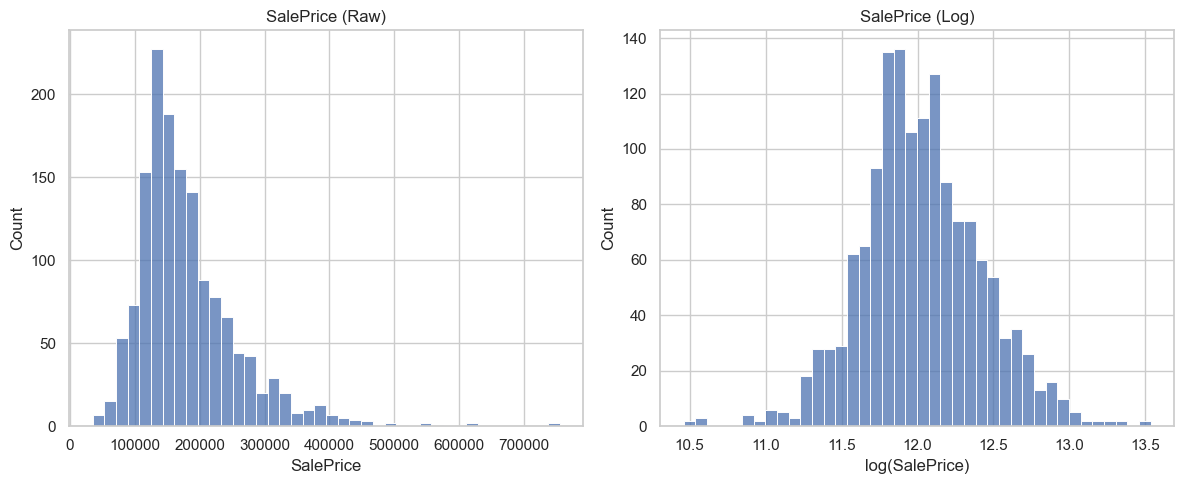

In [185]:
# Plot SalePrice distributions: raw vs log-transformed

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) Raw SalePrice (exponentiate log if raw not present)
sns.histplot(
    np.exp(df["SalePrice_log"]),
    bins=40,
    ax=axes[0]
)
axes[0].set_title("SalePrice (Raw)")
axes[0].set_xlabel("SalePrice")

# 2) Log-transformed SalePrice
sns.histplot(
    df["SalePrice_log"],
    bins=40,
    ax=axes[1]
)
axes[1].set_title("SalePrice (Log)")
axes[1].set_xlabel("log(SalePrice)")

plt.tight_layout()
plt.show()



 The raw SalePrice distribution is highly right-skewed, with many moderately priced houses and a small number of very expensive properties. This skewness can violate the assumptions of linear and generalized linear models and give excessive influence to extreme values.

To address this, the natural logarithm of SalePrice was used. After log transformation, the distribution becomes much more symmetric and closer to a normal shape. This makes the relationship between predictors and the target variable more linear and improves model stability and interpretability.

For these reasons, log(SalePrice) was used as the response variable in the GLM instead of the raw SalePrice.

## 

In [186]:
#SelectING a reasonable starter set of variables
features = [
    "OverallQual",
    "GrLivArea_log",
    "TotalBsmtSF_log",
    "GarageCars",
    "Home_Age",
    "KitchenQual",
    "Fireplaces",
    "CentralAir",
    "LotArea_log"
]

df_model = df[features + ["SalePrice_log"]].copy()


In [187]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)


In [188]:
#FULL GLM model = baseline
X_train = train_df.drop(columns="SalePrice_log")
y_train = train_df["SalePrice_log"]

X_train = sm.add_constant(X_train)

glm_full = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Gaussian()
).fit()

print(glm_full.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:          SalePrice_log   No. Observations:                 1168
Model:                            GLM   Df Residuals:                     1158
Model Family:                Gaussian   Df Model:                            9
Link Function:               Identity   Scale:                        0.022575
Method:                          IRLS   Log-Likelihood:                 561.59
Date:                Sun, 14 Dec 2025   Deviance:                       26.142
Time:                        12:35:58   Pearson chi2:                     26.1
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9969
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.5394      0.133     

A full Generalized Linear Model (GLM) with a Gaussian family and identity link was fitted using log-transformed SalePrice as the response variable. The model includes key structural, size-related and quality-related housing characteristics such as overall quality, living area, basement size, garage capacity, lot size, and age of the house.

Log-transformed variables were used for highly skewed features to reduce the influence of extreme values and improve model assumptions. The full model serves as a baseline model before model reduction.

All included predictors are statistically significant (p < 0.001), indicating that each variable contributes meaningfully to explaining variation in house prices. The negative coefficient for house age shows that older houses tend to have lower prices, while positive coefficients for quality, size, and amenities (e.g. garage, fireplaces, central air) indicate higher prices.

This full model is later compared to reduced models using AIC in order to identify a minimum adequate model that explains SalePrice with fewer predictors while maintaining good model performance.

In [189]:
#null model
null_model = sm.GLM(
    y_train,
    sm.add_constant(pd.Series(1, index=y_train.index)),
    family=sm.families.Gaussian()
).fit()

print("Null model AIC:", null_model.aic)
print("Full model AIC:", glm_full.aic)


Null model AIC: 1119.6695251050246
Full model AIC: -1103.1772684048815


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)


To evaluate whether the selected housing features meaningfully explain house prices, a null model was estimated as a baseline. The null model includes only an intercept and assumes that all houses have the same expected sale price, regardless of their characteristics.

The full GLM model, which includes variables such as house quality, living area, basement size, garage capacity, age, and other features, was then compared to this null model using the Akaike Information Criterion (AIC).

The results show that the full model has a much lower AIC than the null model, indicating a substantially better fit. This confirms that the included housing characteristics provide important explanatory power and that the model performs far better than a model without predictors.

In [190]:
#Model reduction
current_model = glm_full
current_X = X_train.copy()
current_aic = current_model.aic

while True:
    pvals = current_model.pvalues.drop("const")
    worst_var = pvals.idxmax()
    worst_p = pvals.max()

    if worst_p < 0.05:
        break

    candidate_X = current_X.drop(columns=[worst_var])

    candidate_model = sm.GLM(
        y_train,
        candidate_X,
        family=sm.families.Gaussian()
    ).fit()

    if candidate_model.aic < current_aic:
        current_model = candidate_model
        current_X = candidate_X
        current_aic = candidate_model.aic
    else:
        break

print(current_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:          SalePrice_log   No. Observations:                 1168
Model:                            GLM   Df Residuals:                     1158
Model Family:                Gaussian   Df Model:                            9
Link Function:               Identity   Scale:                        0.022575
Method:                          IRLS   Log-Likelihood:                 561.59
Date:                Sun, 14 Dec 2025   Deviance:                       26.142
Time:                        12:35:58   Pearson chi2:                     26.1
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9969
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.5394      0.133     

After fitting the full GLM, a model reduction was performed to obtain a minimum adequate model. Variables with the highest p-values were tested for removal one at a time. A variable was only removed if its removal improved the model according to the AIC criterion. This process stopped when removing any further variable increased AIC. The final model retained only statistically significant predictors (p < 0.05). Key variables such as overall quality, living area, lot size, garage capacity, and home age remained important. The final model is simpler, easier to interpret, and still explains house prices very well.

In [191]:
print("Final model AIC:", current_model.aic)
print("Null model AIC:", null_model.aic)


Final model AIC: -1103.1772684048815
Null model AIC: 1119.6695251050246


In [192]:
#Predict on test set
X_test = test_df.drop(columns="SalePrice_log")
X_test = sm.add_constant(X_test)

test_df["log_pred"] = current_model.predict(X_test)
test_df["price_pred"] = np.exp(test_df["log_pred"])

test_df[["SalePrice_log", "log_pred", "price_pred"]].head()
# Evaluate on test set

,SalePrice_log,log_pred,price_pred
892,11.947956,11.787422,131586.781137
1105,12.691584,12.597434,295798.638039
413,11.652696,11.732056,124499.380526
522,11.976666,11.991417,161363.769036
1036,12.661917,12.652839,312649.802284


The final GLM was applied to the test dataset to evaluate its predictive performance. The model first predicts house prices on the log scale and then converts them back to actual prices using exponentiation. This makes the predictions easier to interpret in real monetary terms. The table shows that predicted prices are close to the observed values, indicating good model performance. Small differences between predicted and actual prices are expected due to unobserved factors. Overall, the model generalizes well to unseen data.

In [193]:
comparison = test_df[["SalePrice_log", "log_pred"]].copy()
comparison["actual_price"] = np.exp(comparison["SalePrice_log"])
comparison["predicted_price"] = np.exp(comparison["log_pred"])

comparison.head()


,SalePrice_log,log_pred,actual_price,predicted_price
892,11.947956,11.787422,154501.0,131586.781137
1105,12.691584,12.597434,325001.0,295798.638039
413,11.652696,11.732056,115001.0,124499.380526
522,11.976666,11.991417,159001.0,161363.769036
1036,12.661917,12.652839,315501.0,312649.802284


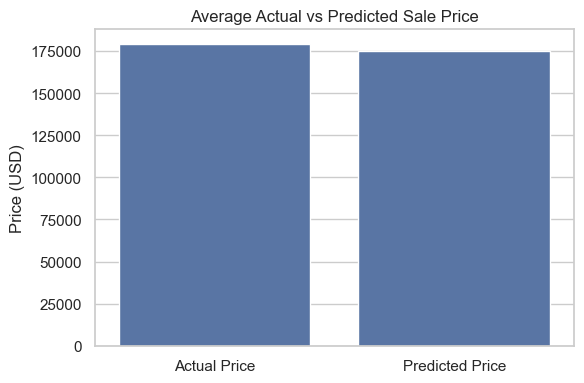

In [194]:
# Back-transform to original price scale
test_df["actual_price"] = np.exp(test_df["SalePrice_log"])
test_df["predicted_price"] = np.exp(test_df["log_pred"])

avg_prices = pd.DataFrame({
    "Type": ["Actual Price", "Predicted Price"],
    "Average Price": [
        test_df["actual_price"].mean(),
        test_df["predicted_price"].mean()
    ]
})

avg_prices

plt.figure(figsize=(6, 4))

sns.barplot(
    data=avg_prices,
    x="Type",
    y="Average Price"
)

plt.title("Average Actual vs Predicted Sale Price")
plt.ylabel("Price (USD)")
plt.xlabel("")
plt.tight_layout()
plt.show()


To assess the overall performance of the model, predicted house prices were compared with actual sale prices on the original price scale. Log-transformed predictions were converted back to dollar values using exponentiation. The bar chart shows that the average predicted price is very close to the average actual price. This indicates that the model does not systematically overestimate or underestimate house prices. Small differences are expected due to noise and unobserved factors. Overall, this comparison suggests the model provides reliable average predictions.

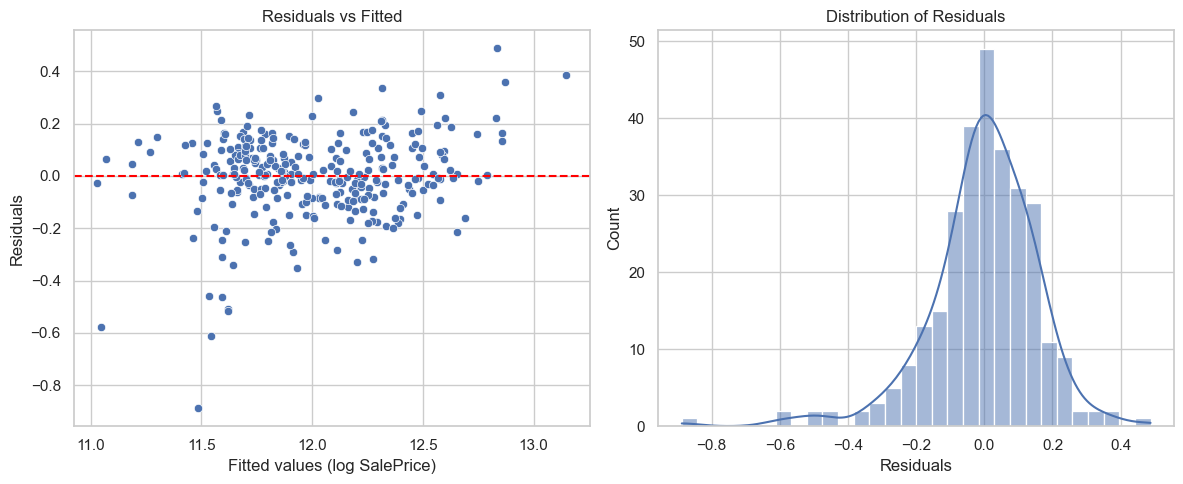

In [195]:
# Calculate residuals
residuals = test_df["SalePrice_log"] - test_df["log_pred"]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) Residuals vs Fitted
sns.scatterplot(
    x=test_df["log_pred"],
    y=residuals,
    ax=axes[0]
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted values (log SalePrice)")
axes[0].set_ylabel("Residuals")

# 2) Residual distribution
sns.histplot(
    residuals,
    bins=30,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

These plots were used to check whether the GLM assumptions are reasonable. The residuals vs fitted plot shows points randomly scattered around zero, indicating no strong pattern and suggesting a good model fit. This means the model does not systematically over- or under-predict for certain price ranges. The residual distribution is approximately bell-shaped and centered around zero, which supports the Gaussian error assumption. A few outliers are present, but this is expected in real housing data. Overall, the residual diagnostics suggest the model fits the data reasonably well.

### Random Forest

In [196]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree

In [197]:
# RF Model
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train1, y_train1)

RandomForestRegressor(n_estimators=200, random_state=42)

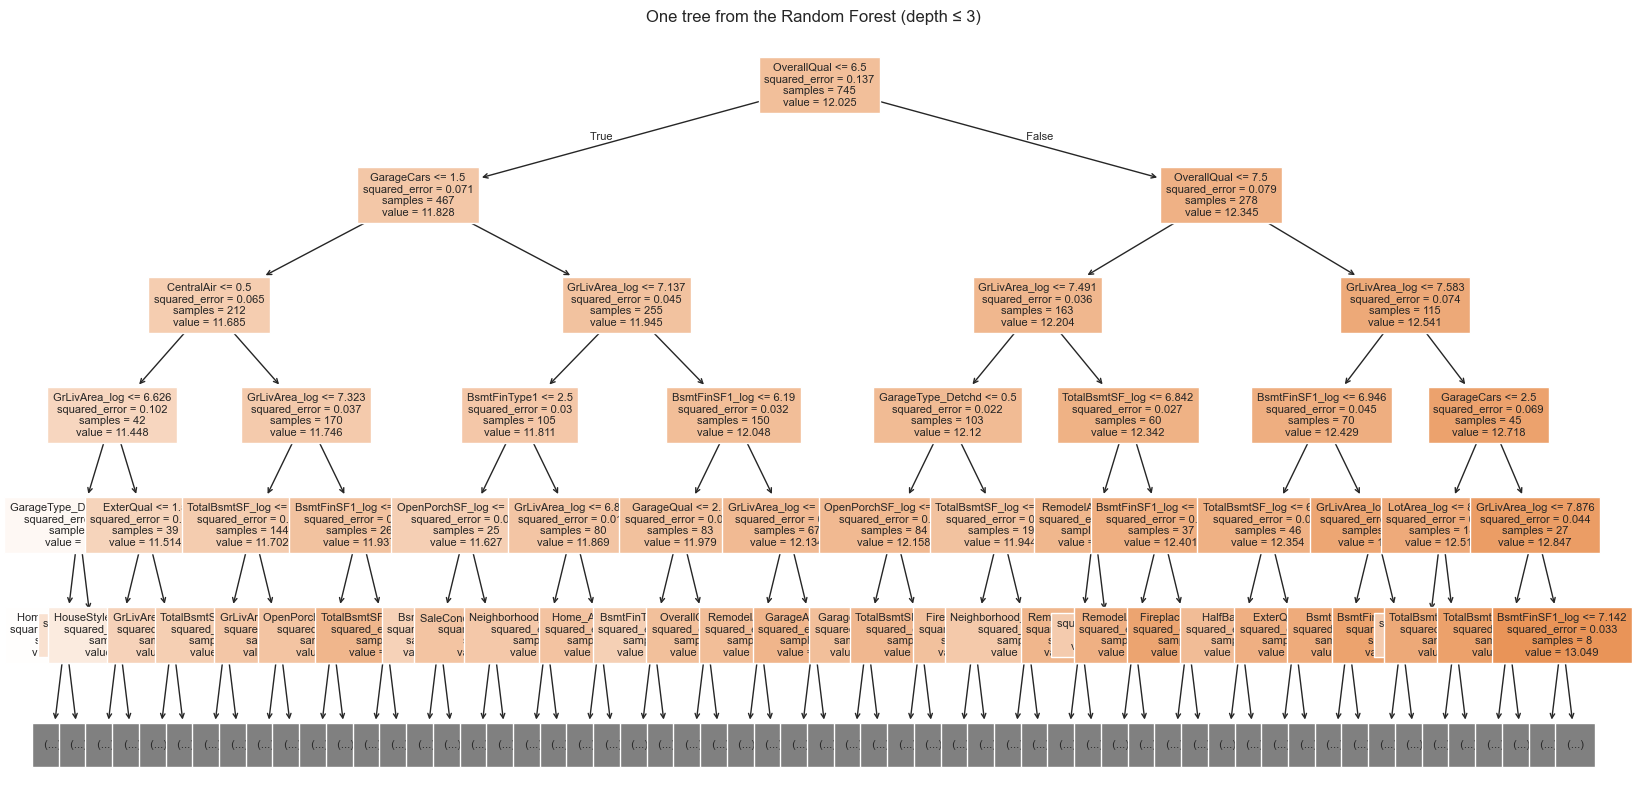

In [198]:
# Take one tree from the forest
tree = rf.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X_train1.columns,
    filled=True,
    max_depth=5, 
    fontsize=8
)
plt.title("One tree from the Random Forest (depth ≤ 3)")
plt.show()

In [199]:
#Prediction
y_pred_log = rf.predict(X_test1)

# Metrics in log
rmse_log = np.sqrt(mean_squared_error(y_test1, y_pred_log))
r2_log = r2_score(y_test1, y_pred_log)

print("RF RMSE (log):", rmse_log)
print("RF R2 (log):", r2_log)

RF RMSE (log): 0.15203555850806358
RF R2 (log): 0.8761337088151652


In [200]:
y_test_orig = np.exp(y_test1)
y_pred_orig = np.exp(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2 = r2_score(y_test_orig, y_pred_orig)

print("RF RMSE:", rmse)
print("RF R2:", r2)

RF RMSE: 29452.804974849907
RF R2: 0.8869060197109059


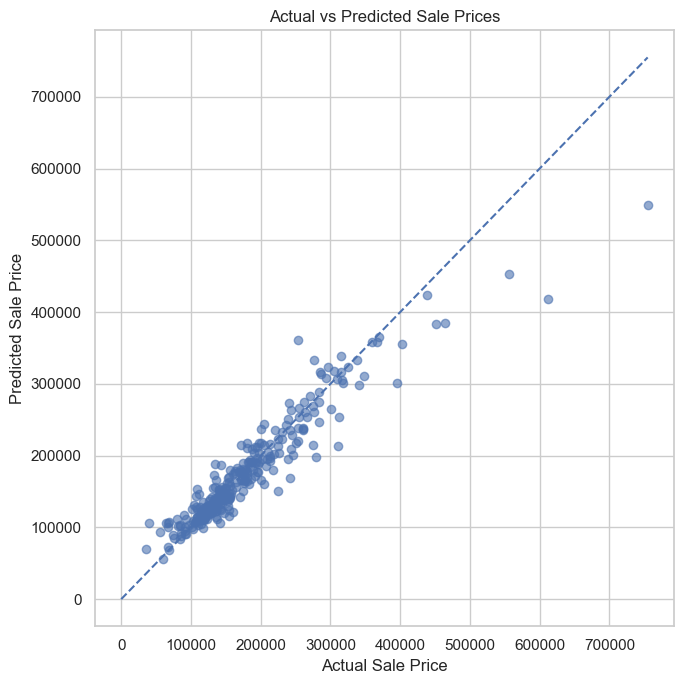

In [201]:
#Actual vs Predicted

plt.figure(figsize=(7, 7))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.6)

max_price = max(y_test_orig.max(), y_pred_orig.max())
plt.plot([0, max_price], [0, max_price], linestyle='--')

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Prices")

plt.tight_layout()
plt.show()

In [202]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X_train1.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(20))

OverallQual          0.548089
GrLivArea_log        0.131496
TotalBsmtSF_log      0.058970
GarageCars           0.047910
BsmtFinSF1_log       0.026670
LotArea_log          0.023699
Home_Age             0.020125
CentralAir           0.017157
GarageAge            0.013671
RemodelAge           0.012457
FireplaceQu          0.011464
OpenPorchSF_log      0.009352
BsmtQual             0.009229
GarageType_Detchd    0.007157
BsmtFinType1         0.005619
WoodDeckSF_log       0.005301
BsmtCond             0.003978
BsmtExposure         0.003813
MasVnrArea_log       0.003544
GarageQual           0.003445
dtype: float64


In [203]:
#Model Reduction using AIC

def stepwise_aic(X, y):
    included = []
    changed = True
    
    while changed:
        changed = False
        
        # Forward step
        excluded = [col for col in X.columns if col not in included]
        best_aic = None
        best_feature = None
        
        for feature in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [feature]])).fit()
            if best_aic is None or model.aic < best_aic:
                best_aic = model.aic
                best_feature = feature
        
        if best_feature is not None:
            included.append(best_feature)
            changed = True
    
    return included

selected_features = stepwise_aic(X_train1, y_train1)
print("Selected features:", selected_features)


Selected features: ['OverallQual', 'GrLivArea_log', 'Home_Age', 'LotArea_log', 'BsmtFinSF1_log', 'KitchenQual', 'GarageCars', 'RemodelAge', 'FireplaceQu', 'CentralAir', 'BsmtQual', 'HouseStyle_1Story', 'BsmtExposure', 'Neighborhood_Edwards', 'Neighborhood_OldTown', 'Foundation_PConc', 'GarageType_Other', 'Neighborhood_NridgHt', 'Neighborhood_Somerst', 'BsmtFullBath', 'BldgType_Other', 'Neighborhood_Other', 'BldgType_TwnhsE', 'HouseStyle_Other', 'HalfBath', 'FullBath', 'ExterQual', 'SaleCondition_Normal', 'SaleCondition_Partial', 'SaleCondition_Other', 'BsmtCond', 'TotalBsmtSF_log', 'Neighborhood_Gilbert', 'MasVnrArea_log', 'LotShape_Reg', 'GarageQual', 'GarageAge', 'Neighborhood_Sawyer', 'Fireplaces', 'WoodDeckSF_log', 'Foundation_Other', 'Foundation_CBlock', 'EnclosedPorch_log', 'BedroomAbvGr', 'BsmtFinType1', 'OpenPorchSF_log', 'Neighborhood_NAmes', 'HouseStyle_2Story', 'GarageType_BuiltIn', 'GarageType_Detchd']


In [204]:
#Reduced RF Model

X_train_red = X_train1[selected_features]
X_test_red = X_test1[selected_features]

rf_red = RandomForestRegressor(n_estimators=200, random_state=42)
rf_red.fit(X_train_red, y_train1)

#Prediction
y_pred_red_log = rf_red.predict(X_test_red)

rmse_red = np.sqrt(mean_squared_error(y_test1, y_pred_red_log))
r2_red = r2_score(y_test1, y_pred_red_log)

print("Reduced RF RMSE (log):", rmse_red)
print("Reduced RF R2 (log):", r2_red)


Reduced RF RMSE (log): 0.15212493271213426
Reduced RF R2 (log): 0.8759880362477666


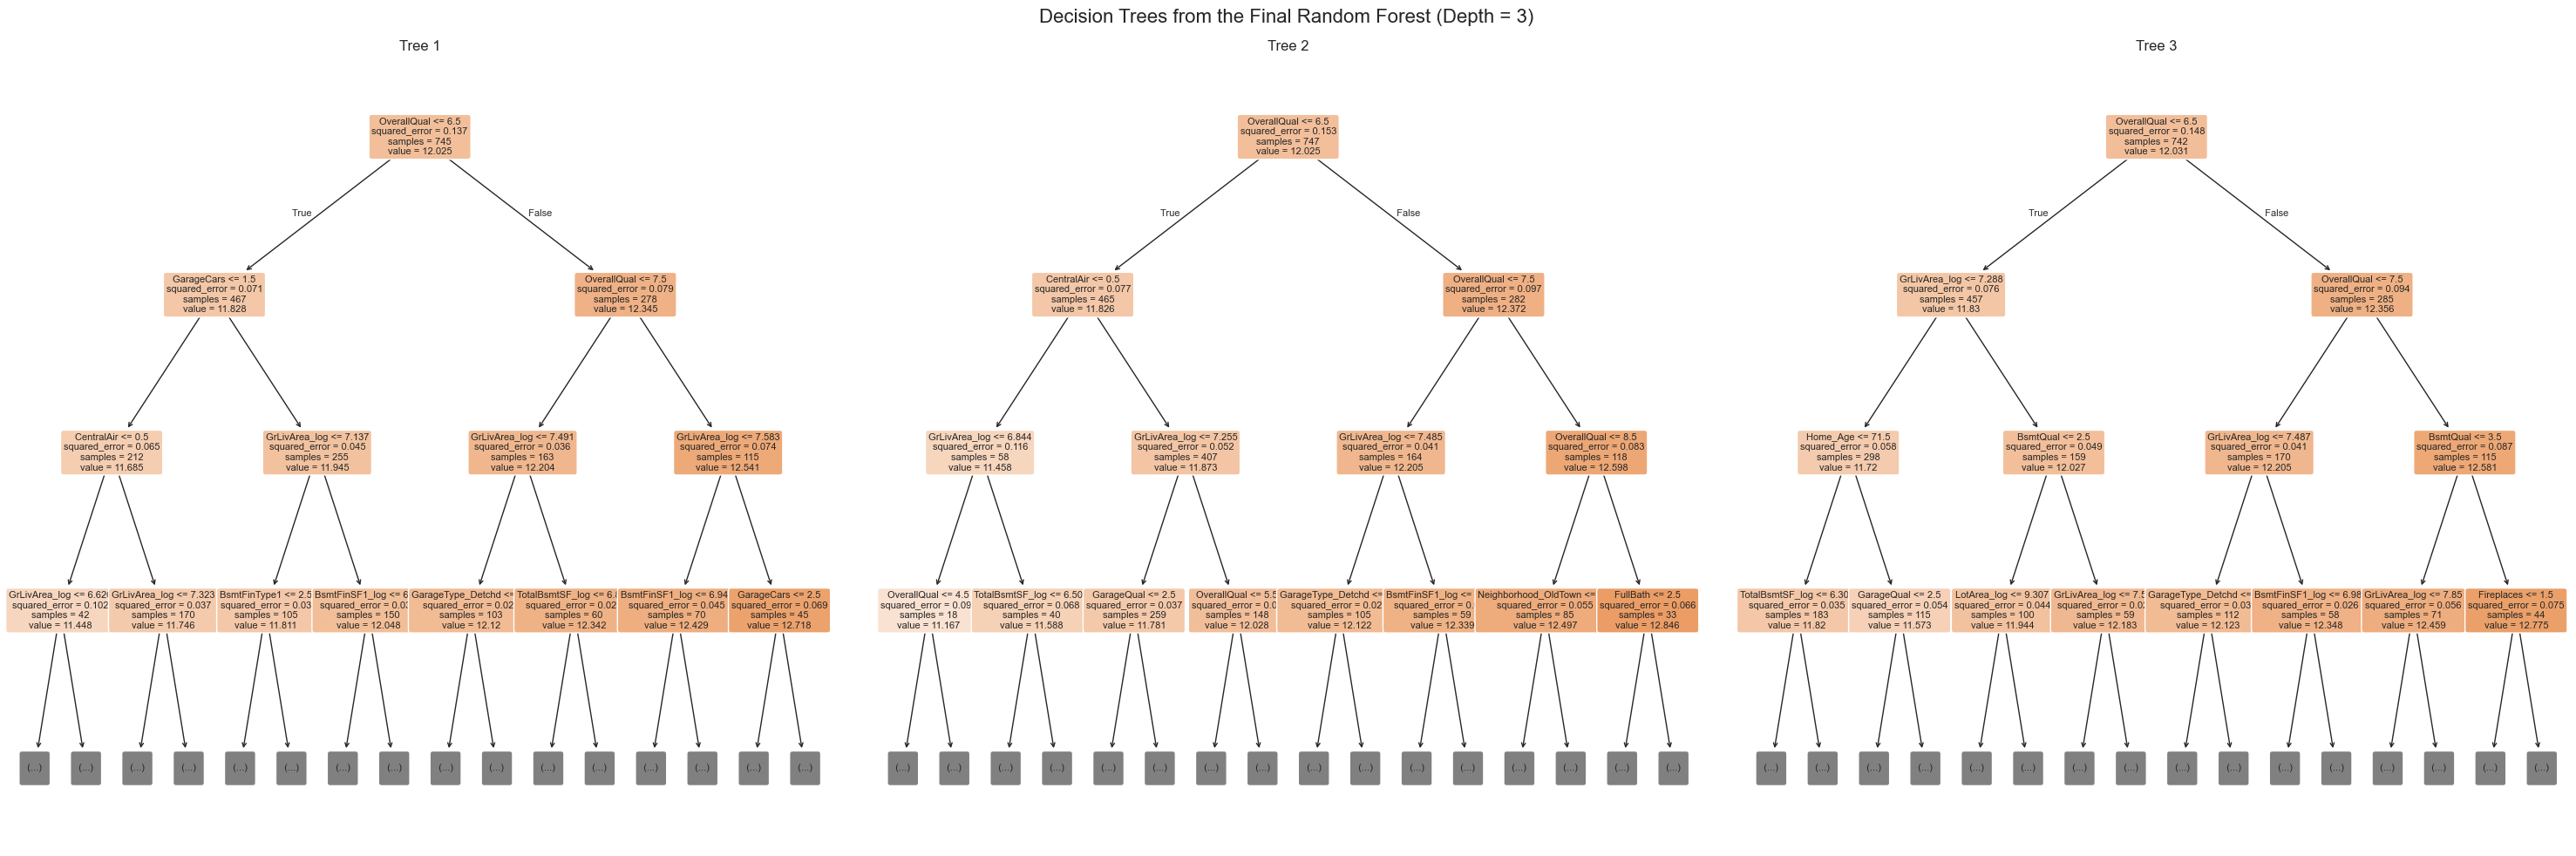

In [205]:
# Three different trees from the final RF

trees = rf_red.estimators_[:3]

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

for i, tree in enumerate(trees):
    plot_tree(
        tree,
        feature_names=X_train_red.columns,
        filled=True,
        max_depth=3,        # MUST keep this
        rounded=True,
        fontsize=8,
        ax=axes[i]
    )
    axes[i].set_title(f"Tree {i+1}")

plt.suptitle(
    "Decision Trees from the Final Random Forest (Depth = 3)",
    fontsize=16
)

plt.tight_layout()
plt.show()

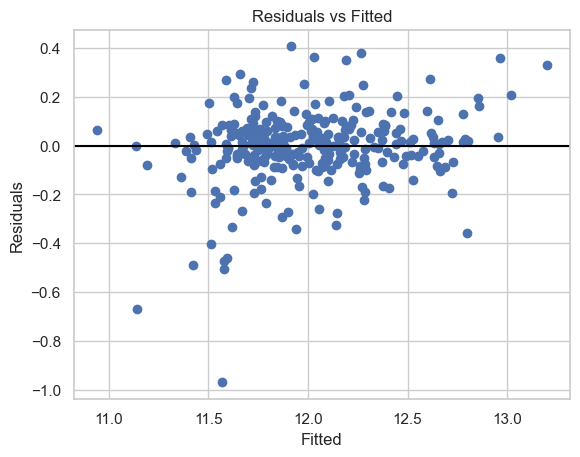

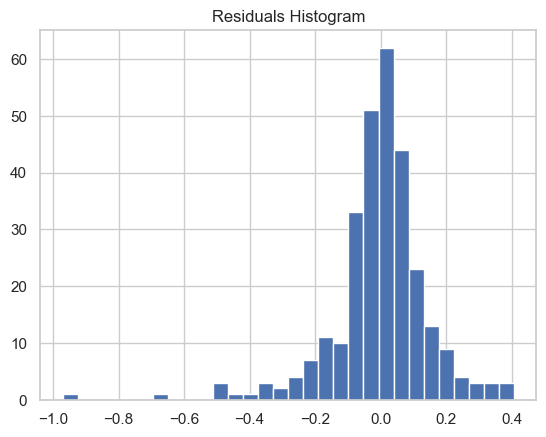

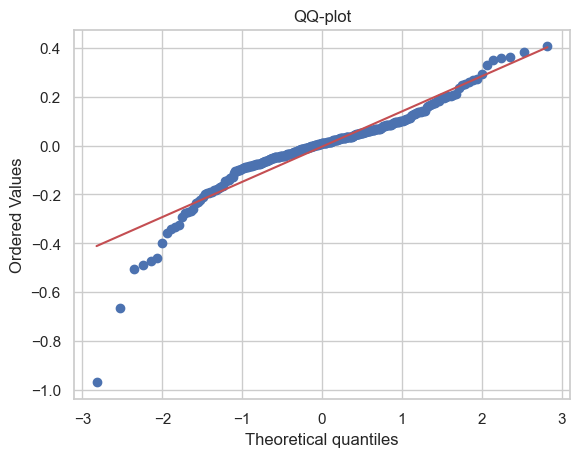

In [206]:
#Residuals

residuals = y_test1 - y_pred_red_log

plt.scatter(y_pred_red_log, residuals)
plt.axhline(0, color="black")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

plt.hist(residuals, bins=30)
plt.title("Residuals Histogram")
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-plot")
plt.show()